In [61]:
import wfdb
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

In [62]:
DATA_DIR = './ludb_data'
DB_NAME = 'ludb'
TARGET_FREQ = 500
NUM_CLASSES = 4

CLASS_MAP = {
    'p': 1,   # P-wave
    'N': 2,   # QRS complex (Normal beat)
    't': 3    # T-wave
}

In [63]:
def parse_record(record_path, lead_name='ii'):
    """
    Reads the signal and annotations for a specific lead and creates a segmentation mask.
    """
    record = wfdb.rdrecord(record_path)
    lead_names = [sig_name.lower() for sig_name in record.sig_name]
    if lead_name.lower() not in lead_names:
        raise ValueError(f"Lead {lead_name} not found in record.")
    lead_idx = lead_names.index(lead_name.lower())

    signal = record.p_signal[:, lead_idx]
    signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
    signal_length = len(signal)

    try:
        annotation = wfdb.rdann(record_path, extension=lead_name)
    except FileNotFoundError:
        print(f"No annotations found for {record_path} lead {lead_name}")
        return signal, np.zeros(signal_length)

    mask = np.zeros(signal_length, dtype=np.int64)
    current_wave_type = None
    onset_idx = -1

    for sym, sample in zip(annotation.symbol, annotation.sample):
        if sym == '(':  # Onset of a wave
            onset_idx = sample
        elif sym in CLASS_MAP:  # Peak of the wave (identifies the type)
            current_wave_type = CLASS_MAP[sym]
        elif sym == ')':  # Offset of a wave
            if onset_idx != -1 and current_wave_type is not None:
                # Fill the mask interval with the class integer
                mask[onset_idx:sample] = current_wave_type
            onset_idx = -1
            current_wave_type = None

    return signal, mask

In [80]:
def prepare_dataset_for_pytorch():
    records = wfdb.get_record_list(DB_NAME)
    X_data = []
    y_data = []

    print("Parsing records...")
    for rec in records:
        record_path = os.path.join(DATA_DIR, rec)
        try:
            signal, mask = parse_record(record_path, lead_name='ii')
            X_data.append(signal)
            y_data.append(mask)
        except Exception as e:
            pass

    X_tensor = torch.tensor(np.array(X_data), dtype=torch.float32).unsqueeze(1)
    y_tensor = torch.tensor(np.array(y_data), dtype=torch.long)

    print(f"Dataset prepared!")
    print(f"Input Data Shape: {X_tensor.shape}")
    print(f"Target Mask Shape: {y_tensor.shape}")

    return X_tensor, y_tensor


X, y = prepare_dataset_for_pytorch()

Parsing records...
Dataset prepared!
Input Data Shape: torch.Size([200, 1, 5000])
Target Mask Shape: torch.Size([200, 5000])


In [65]:
def preprocess_signal(signal: np.ndarray, orig_freq: float, target_freq: float = 500.0) -> np.ndarray:
    """
    Resamples the ECG signal to the target frequency using cubic splines.
    """
    n = len(signal)
    T = n / orig_freq # Signal duration
    t = (2 * np.arange(1, n + 1) - 1) * T / (2 * n)

    cs = CubicSpline(t, signal)

    m = int(np.ceil(target_freq * T))
    t_prime = (2 * np.arange(1, m + 1) - 1) * T / (2 * m)

    resampled_signal = cs(t_prime)
    return resampled_signal

In [66]:
class ConvBlock(nn.Module):
    """
    Two convolutional layers each with batch normalization and Relu activation.
    All convolutional layers have kernel-size = 15, padding = 7.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=15, padding=7)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=15, padding=7)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        return x


class ECGUNetPlusPlus(nn.Module):
    def __init__(self, in_channels=1, num_classes=4):
        super().__init__()
        filters = [16, 32, 64, 128, 256]

        # Encoder (Downsampling path / Column 0)
        self.conv0_0 = ConvBlock(in_channels, filters[0])
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv1_0 = ConvBlock(filters[0], filters[1])
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv2_0 = ConvBlock(filters[1], filters[2])
        self.pool3 = nn.MaxPool1d(kernel_size=2)

        self.conv3_0 = ConvBlock(filters[2], filters[3])
        self.pool4 = nn.MaxPool1d(kernel_size=2)

        # Bottleneck
        self.conv4_0 = ConvBlock(filters[3], filters[4])

        # Upsampling Paths and Dense Skip Connections
        # Column 1
        self.up1_0 = nn.ConvTranspose1d(filters[1], filters[0], kernel_size=8, stride=2, padding=3)
        self.conv0_1 = ConvBlock(filters[0]*2, filters[0])

        self.up2_0 = nn.ConvTranspose1d(filters[2], filters[1], kernel_size=8, stride=2, padding=3)
        self.conv1_1 = ConvBlock(filters[1]*2, filters[1])

        self.up3_0 = nn.ConvTranspose1d(filters[3], filters[2], kernel_size=8, stride=2, padding=3)
        self.conv2_1 = ConvBlock(filters[2]*2, filters[2])

        self.up4_0 = nn.ConvTranspose1d(filters[4], filters[3], kernel_size=8, stride=2, padding=3)
        self.conv3_1 = ConvBlock(filters[3]*2, filters[3])

        # Column 2
        self.up1_1 = nn.ConvTranspose1d(filters[1], filters[0], kernel_size=8, stride=2, padding=3)
        self.conv0_2 = ConvBlock(filters[0]*3, filters[0])

        self.up2_1 = nn.ConvTranspose1d(filters[2], filters[1], kernel_size=8, stride=2, padding=3)
        self.conv1_2 = ConvBlock(filters[1]*3, filters[1])

        self.up3_1 = nn.ConvTranspose1d(filters[3], filters[2], kernel_size=8, stride=2, padding=3)
        self.conv2_2 = ConvBlock(filters[2]*3, filters[2])

        # Column 3
        self.up1_2 = nn.ConvTranspose1d(filters[1], filters[0], kernel_size=8, stride=2, padding=3)
        self.conv0_3 = ConvBlock(filters[0]*4, filters[0])

        self.up2_2 = nn.ConvTranspose1d(filters[2], filters[1], kernel_size=8, stride=2, padding=3)
        self.conv1_3 = ConvBlock(filters[1]*4, filters[1])

        # Column 4 (Final Decoder output)
        self.up1_3 = nn.ConvTranspose1d(filters[1], filters[0], kernel_size=8, stride=2, padding=3)
        self.conv0_4 = ConvBlock(filters[0]*5, filters[0])

        # Final output layer
        self.out_conv = nn.Conv1d(filters[0], num_classes, kernel_size=1)

    def pad_to_match(self, x, skip_connection):
        """
        Implements zero padding to match dimensions before concatenation.
        """
        diff = skip_connection.size(-1) - x.size(-1)
        if diff > 0:
            x = F.pad(x, (0, diff))
        return x

    def forward(self, x):
        # Column 0 (Encoder)
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool1(x0_0))
        x2_0 = self.conv2_0(self.pool2(x1_0))
        x3_0 = self.conv3_0(self.pool3(x2_0))
        x4_0 = self.conv4_0(self.pool4(x3_0))

        # Column 1
        u1_0 = self.pad_to_match(self.up1_0(x1_0), x0_0)
        x0_1 = self.conv0_1(torch.cat([x0_0, u1_0], dim=1))

        u2_0 = self.pad_to_match(self.up2_0(x2_0), x1_0)
        x1_1 = self.conv1_1(torch.cat([x1_0, u2_0], dim=1))

        u3_0 = self.pad_to_match(self.up3_0(x3_0), x2_0)
        x2_1 = self.conv2_1(torch.cat([x2_0, u3_0], dim=1))

        u4_0 = self.pad_to_match(self.up4_0(x4_0), x3_0)
        x3_1 = self.conv3_1(torch.cat([x3_0, u4_0], dim=1))

        # Column 2
        u1_1 = self.pad_to_match(self.up1_1(x1_1), x0_1)
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, u1_1], dim=1))

        u2_1 = self.pad_to_match(self.up2_1(x2_1), x1_1)
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, u2_1], dim=1))

        u3_1 = self.pad_to_match(self.up3_1(x3_1), x2_1)
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, u3_1], dim=1))

        # Column 3
        u1_2 = self.pad_to_match(self.up1_2(x1_2), x0_2)
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, u1_2], dim=1))

        u2_2 = self.pad_to_match(self.up2_2(x2_2), x1_2)
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, u2_2], dim=1))

        # Column 4
        u1_3 = self.pad_to_match(self.up1_3(x1_3), x0_3)
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, u1_3], dim=1))

        # Final Convolution
        out = self.out_conv(x0_4)
        return out

In [67]:
print("Splitting data...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X.numpy(),
    y.numpy(),
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)


Splitting data...


In [68]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [B, C, L]
        # targets: [B, L]

        num_classes = logits.shape[1]

        probs = F.softmax(logits, dim=1)

        targets_onehot = F.one_hot(
            targets, num_classes=num_classes
        ).permute(0, 2, 1).float()  # [B,C,L]

        intersection = (probs * targets_onehot).sum(dim=(0, 2))
        union = probs.sum(dim=(0, 2)) + targets_onehot.sum(dim=(0, 2))

        dice = (2 * intersection + self.smooth) / (
            union + self.smooth
        )

        return 1 - dice.mean()

In [69]:
all_labels = y_train.flatten()

class_counts = torch.bincount(torch.tensor(all_labels), minlength=4)

weights = 1.0 / class_counts.float()
weights = weights / weights.sum() * len(weights)

print(weights)

tensor([0.1761, 1.6233, 1.3716, 0.8290])


In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [71]:
ce_loss = nn.CrossEntropyLoss(weight=weights.to(device))
dice_loss = DiceLoss()

In [72]:
def train_model(X_train, y_train, X_test, y_test):
    
    X_train = torch.tensor(X_train)
    y_train = torch.tensor(y_train)
    X_test = torch.tensor(X_test)
    y_test = torch.tensor(y_test)

    batch_size = 16
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Initializing model on {device}...")

    model = ECGUNetPlusPlus(in_channels=1, num_classes=4).to(device)
    ce_loss = nn.CrossEntropyLoss(weight=weights.to(device))
    dice_loss = DiceLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    num_epochs = 300
    print("Starting training...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)

            loss_ce = ce_loss(outputs, targets)
            loss_dice = dice_loss(outputs, targets)

            loss = 0.3 * loss_ce + 0.7  * loss_dice

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    print("Training finished!")
    return model, X_test, y_test


trained_model, X_test, y_test = train_model(X_train, y_train, X_test, y_test)

Initializing model on cuda...
Starting training...
Epoch [1/300], Loss: 0.8022
Epoch [2/300], Loss: 0.6288
Epoch [3/300], Loss: 0.5780
Epoch [4/300], Loss: 0.5426
Epoch [5/300], Loss: 0.5143
Epoch [6/300], Loss: 0.4858
Epoch [7/300], Loss: 0.4622
Epoch [8/300], Loss: 0.4364
Epoch [9/300], Loss: 0.4123
Epoch [10/300], Loss: 0.3912
Epoch [11/300], Loss: 0.3683
Epoch [12/300], Loss: 0.3448
Epoch [13/300], Loss: 0.3252
Epoch [14/300], Loss: 0.3032
Epoch [15/300], Loss: 0.2828
Epoch [16/300], Loss: 0.2632
Epoch [17/300], Loss: 0.2477
Epoch [18/300], Loss: 0.2303
Epoch [19/300], Loss: 0.2123
Epoch [20/300], Loss: 0.2000
Epoch [21/300], Loss: 0.1965
Epoch [22/300], Loss: 0.1998
Epoch [23/300], Loss: 0.1877
Epoch [24/300], Loss: 0.1864
Epoch [25/300], Loss: 0.1690
Epoch [26/300], Loss: 0.1582
Epoch [27/300], Loss: 0.1512
Epoch [28/300], Loss: 0.1485
Epoch [29/300], Loss: 0.1471
Epoch [30/300], Loss: 0.1454
Epoch [31/300], Loss: 0.1355
Epoch [32/300], Loss: 0.1335
Epoch [33/300], Loss: 0.1286
E

Sample 0 Pixel-wise Accuracy: 83.46%


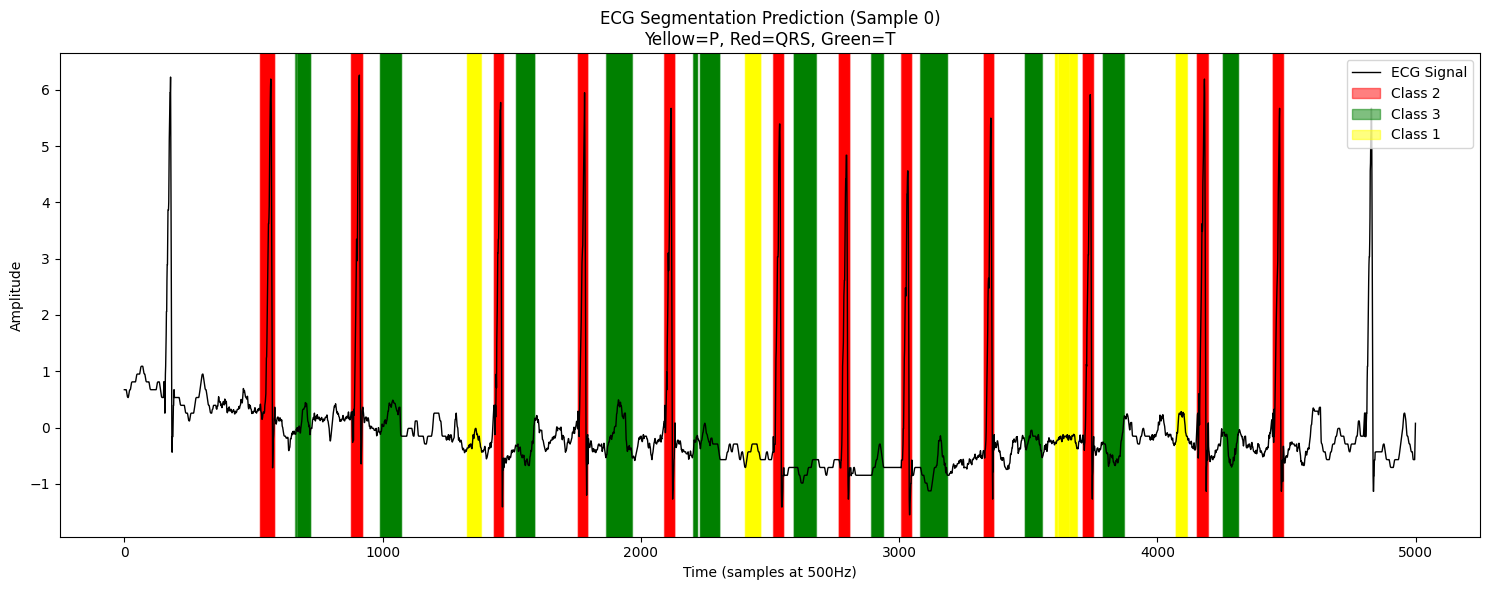

In [76]:
def evaluate_and_visualize(model, X_test, y_test, sample_idx=0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    # Shape: (1, 1, 5000)
    sample_x = X_test[sample_idx].unsqueeze(0).to(device)
    true_y = y_test[sample_idx].numpy()

    with torch.no_grad():
        output = model(sample_x)
        predicted_y = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    correct_pixels = (predicted_y == true_y).sum()
    total_pixels = len(true_y)
    accuracy = (correct_pixels / total_pixels) * 100
    print(f"Sample {sample_idx} Pixel-wise Accuracy: {accuracy:.2f}%")

    signal = sample_x.squeeze().cpu().numpy()
    time_steps = range(len(signal))

    plt.figure(figsize=(15, 6))

    plt.plot(time_steps, signal, color='black', linewidth=1, label='ECG Signal')

    colors = {1: 'yellow', 2: 'red', 3: 'green'}
    labels_plotted = set()

    for i in range(1, len(predicted_y)):
        current_class = predicted_y[i]
        if current_class in colors:
            label = f"Class {current_class}" if current_class not in labels_plotted else ""
            plt.axvspan(i-1, i, color=colors[current_class], alpha=0.5, label=label)
            labels_plotted.add(current_class)

    plt.title(f"ECG Segmentation Prediction (Sample {sample_idx})\nYellow=P, Red=QRS, Green=T")
    plt.xlabel("Time (samples at 500Hz)")
    plt.ylabel("Amplitude")

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right')

    plt.tight_layout()
    plt.show()

evaluate_and_visualize(trained_model, X_test, y_test, sample_idx=0)

Successfully evaluated 30 test samples.
Average Pixel-wise Accuracy: 93.72%



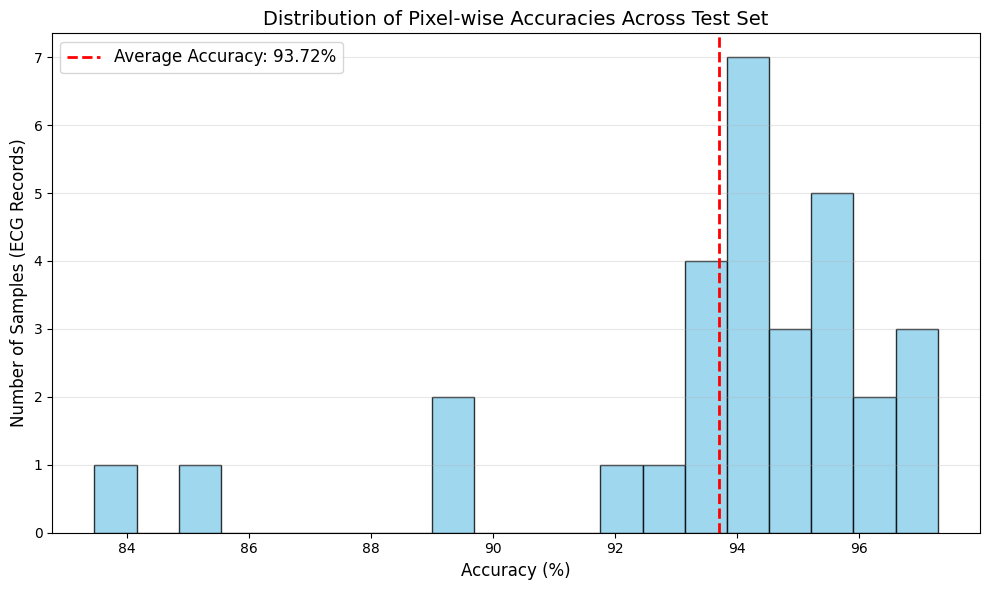

In [77]:
def evaluate_all_samples(model, X_test, y_test):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    accuracies = []
    with torch.no_grad():
        for i in range(len(X_test)):
            sample_x = X_test[i].unsqueeze(0).to(device)
            true_y = y_test[i].numpy()

            output = model(sample_x)
            predicted_y = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            correct_pixels = (predicted_y == true_y).sum()
            total_pixels = len(true_y)
            accuracy = (correct_pixels / total_pixels) * 100

            accuracies.append(accuracy)

    average_accuracy = np.mean(accuracies)

    print(f"Successfully evaluated {len(X_test)} test samples.")
    print(f"Average Pixel-wise Accuracy: {average_accuracy:.2f}%\n")

    # --- Plotting the Distribution ---
    plt.figure(figsize=(10, 6))

    plt.hist(accuracies, bins=20, color='skyblue', edgecolor='black', alpha=0.8)

    plt.axvline(average_accuracy, color='red', linestyle='dashed', linewidth=2,
                label=f'Average Accuracy: {average_accuracy:.2f}%')

    plt.title('Distribution of Pixel-wise Accuracies Across Test Set', fontsize=14)
    plt.xlabel('Accuracy (%)', fontsize=12)
    plt.ylabel('Number of Samples (ECG Records)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    return accuracies, average_accuracy

all_accuracies, avg_acc = evaluate_all_samples(trained_model, X_test, y_test)

In [78]:
def extract_wave_boundaries(mask, class_id):
    """Finds the onset and offset indices for a specific wave class in a 1D mask."""
    boundaries = []
    in_wave = False
    onset = -1

    for i in range(len(mask)):
        if mask[i] == class_id and not in_wave:
            in_wave = True
            onset = i
        elif mask[i] != class_id and in_wave:
            in_wave = False
            offset = i - 1
            boundaries.append((onset, offset))
    if in_wave:
        boundaries.append((onset, len(mask) - 1))

    return boundaries

def smooth_predictions(mask, tolerance_ms=10, sampling_rate=500):
    """
    Fills small gaps in the predicted mask to fix the 'jitter' problem.
    """
    # e.g., 10 ms at 500 Hz = 5 samples
    gap_tolerance = int((tolerance_ms / 1000.0) * sampling_rate)

    smoothed_mask = mask.copy()

    for class_id in [1, 2, 3]:
        boundaries = extract_wave_boundaries(smoothed_mask, class_id)

        if len(boundaries) < 2:
            continue

        for i in range(len(boundaries) - 1):
            current_end = boundaries[i][1]
            next_start = boundaries[i+1][0]
            gap_size = next_start - current_end - 1
            if 0 < gap_size <= gap_tolerance:
                smoothed_mask[current_end + 1 : next_start] = class_id

    return smoothed_mask

def remove_boundary_cycles(mask):
    """
    Removes the first and last cardiac cycles from a segmentation mask
    to prevent false positives from unannotated beats.
    """
    clean_mask = mask.copy()
    qrs_bounds = extract_wave_boundaries(clean_mask, 2)

    if len(qrs_bounds) < 3:
        return clean_mask

    # --- STRIP THE FIRST CYCLE ---
    first_qrs_offset = qrs_bounds[0][1]
    second_qrs_onset = qrs_bounds[1][0]

    # Zeroing out everything up to the end of the 1st QRS
    clean_mask[:first_qrs_offset + 1] = 0

    # Zeroing out the 1st T-wave
    t_bounds = extract_wave_boundaries(clean_mask, 3)
    for start, end in t_bounds:
        if start < second_qrs_onset:
            clean_mask[start:end + 1] = 0

    # --- STRIP THE LAST CYCLE ---
    last_qrs_onset = qrs_bounds[-1][0]
    second_to_last_qrs_offset = qrs_bounds[-2][1]

    # Zeroing out everything from the start of the last QRS to the end of the signal
    clean_mask[last_qrs_onset:] = 0

    # Zeroing out the last P-wave
    p_bounds = extract_wave_boundaries(clean_mask, 1)
    for start, end in p_bounds:
        if end > second_to_last_qrs_offset:
            clean_mask[start:end + 1] = 0

    return clean_mask



def evaluate_ami_standard(model, X_test, y_test, tolerance=75):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    metrics = {
        'P': {'onset': {'TP': 0, 'FP': 0, 'FN': 0}, 'offset': {'TP': 0, 'FP': 0, 'FN': 0}},
        'QRS': {'onset': {'TP': 0, 'FP': 0, 'FN': 0}, 'offset': {'TP': 0, 'FP': 0, 'FN': 0}},
        'T': {'onset': {'TP': 0, 'FP': 0, 'FN': 0}, 'offset': {'TP': 0, 'FP': 0, 'FN': 0}}
    }

    class_map = {1: 'P', 2: 'QRS', 3: 'T'}

    with torch.no_grad():
        for i in range(len(X_test)):
            sample_x = X_test[i].unsqueeze(0).to(device)
            true_y = y_test[i].numpy()

            output = model(sample_x)
            predicted_y = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            predicted_y = smooth_predictions(predicted_y, tolerance_ms=15)

            true_y = remove_boundary_cycles(true_y)
            predicted_y = remove_boundary_cycles(predicted_y)

            for class_id, wave_name in class_map.items():
                true_bounds = extract_wave_boundaries(true_y, class_id)
                pred_bounds = extract_wave_boundaries(predicted_y, class_id)

                for point_type in ['onset', 'offset']:
                    point_idx = 0 if point_type == 'onset' else 1

                    true_points = [b[point_idx] for b in true_bounds]
                    pred_points = [b[point_idx] for b in pred_bounds]

                    matched_true = set()
                    for p in pred_points:
                        valid_matches = [t for t in true_points if abs(t - p) <= tolerance and t not in matched_true]

                        if valid_matches:
                            best_match = min(valid_matches, key=lambda t: abs(t - p))
                            matched_true.add(best_match)
                            metrics[wave_name][point_type]['TP'] += 1
                        else:
                            metrics[wave_name][point_type]['FP'] += 1

                    metrics[wave_name][point_type]['FN'] += len(true_points) - len(matched_true)

    print(f"{'Wave (Point)':<15} | {'Sensitivity (Se)':<18} | {'Precision (PPV)':<18} | {'F1-Score'}")
    print("-" * 75)

    for wave_name in ['P', 'QRS', 'T']:
        for point_type in ['onset', 'offset']:
            m = metrics[wave_name][point_type]

            se = m['TP'] / (m['TP'] + m['FN']) if (m['TP'] + m['FN']) > 0 else 0
            ppv = m['TP'] / (m['TP'] + m['FP']) if (m['TP'] + m['FP']) > 0 else 0
            f1 = 2 * (se * ppv) / (se + ppv) if (se + ppv) > 0 else 0

            label = f"{wave_name} {point_type}"
            print(f"{label:<15} | {se*100:>15.2f}% | {ppv*100:>15.2f}% | {f1*100:>8.2f}%")


evaluate_ami_standard(trained_model, X_test, y_test, tolerance=75)

Wave (Point)    | Sensitivity (Se)   | Precision (PPV)    | F1-Score
---------------------------------------------------------------------------
P onset         |           94.95% |           92.16% |    93.53%
P offset        |           94.95% |           92.16% |    93.53%
QRS onset       |           96.88% |           97.31% |    97.09%
QRS offset      |           96.88% |           97.31% |    97.09%
T onset         |           96.88% |           96.02% |    96.44%
T offset        |           96.88% |           96.02% |    96.44%
